**Step 1: Import Libraries**

In [27]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

**Step 2: Load Dataset & Select Features**

In [28]:
# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("customer_shopping_data.csv")

# -----------------------------
# Select Features
# -----------------------------
features = ["quantity", "price", "totalSpend"]

X = df[features]

**Step 3: Scale all Selected Features**

In [29]:
# -----------------------------
# Scale all selected features
# -----------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Step 4: Use Elbow Method to find cluster size (k size)**

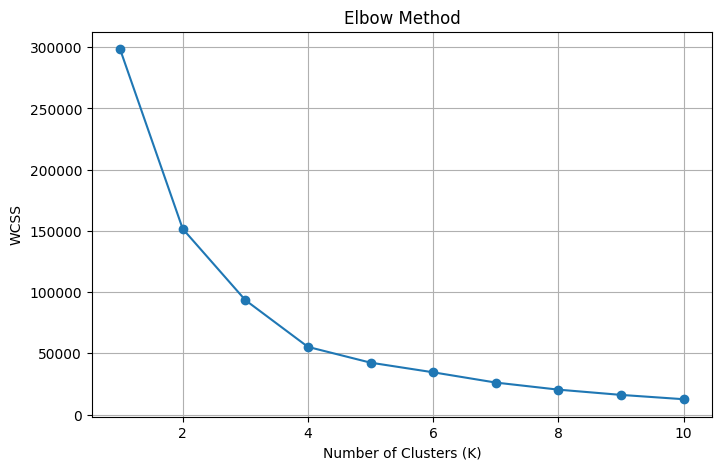

In [30]:
# -----------------------------
# Elbow Method
# -----------------------------
wcss = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

**Step 5: Applying k means and displaying cluster summary and cluster centers**

In [31]:
# -------------------------------------------------
# Choose K based on elbow graph
# (Example: K = 3)
# -------------------------------------------------

optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

# -----------------------------
# Cluster Centers
# -----------------------------
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=features
)

print("\nCluster Centers")
print(centers)

# -----------------------------
# Cluster Summary
# -----------------------------
cluster_summary = df.groupby("Cluster")["totalSpend"].mean().sort_values()
print("\nAverage Total Spend of Each Cluster")
print(cluster_summary)

cluster_order = cluster_summary.index.tolist()

cluster_names = {
    cluster_order[0]: "Low Spending",
    cluster_order[1]: "Medium Spending",
    cluster_order[2]: "High Spending"
}

df["Spending_Category"] = df["Cluster"].map(cluster_names)
print(df[["customer_id", "totalSpend", "Spending_Category"]].head())


Cluster Centers
   quantity     price  totalSpend
0  0.839183  0.031199    0.091680
1 -0.845712 -0.424992   -0.479757
2  0.906662  2.816261    2.837865

Average Total Spend of Each Cluster
Cluster
1      503.036822
0     2915.905214
2    14511.546280
Name: totalSpend, dtype: float64
  customer_id  totalSpend Spending_Category
0     C241288     7502.00   Medium Spending
1     C111565     5401.53   Medium Spending
2     C266599      300.08      Low Spending
3     C988172    15004.25     High Spending
4     C189076      242.40   Medium Spending


**Step 6: Calculating no of customers in each clusters, and plotting the graph**


Customers in each Cluster
Cluster
1    49818
0    42593
2     7046
Name: count, dtype: int64
Spending_Category
Low Spending       49818
Medium Spending    42593
High Spending       7046
Name: count, dtype: int64


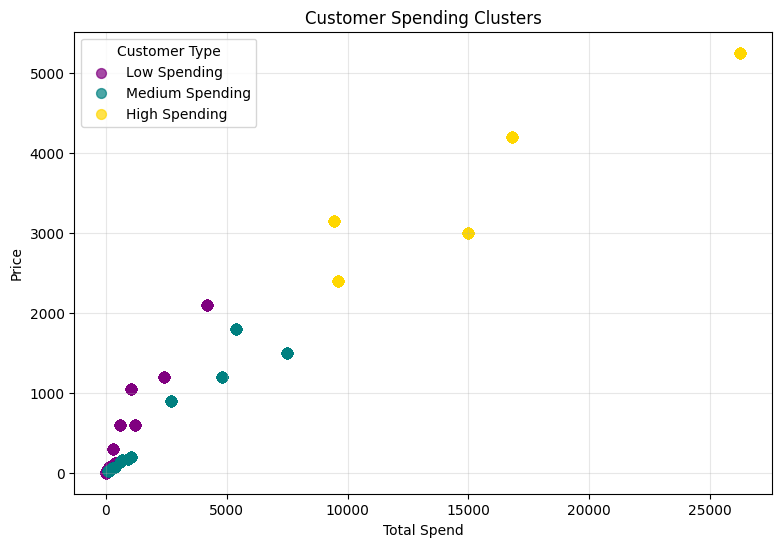


Clustered dataset saved as customer_clusters.csv


In [32]:
# -----------------------------
# Number of Customers
# -----------------------------
print("\nCustomers in each Cluster")
print(df["Cluster"].value_counts())
print(df["Spending_Category"].value_counts())

plt.figure(figsize=(9,6))

colors = {
    "Low Spending": "purple",
    "Medium Spending": "teal",
    "High Spending": "gold"
}

for category, color in colors.items():
    subset = df[df["Spending_Category"] == category]

    plt.scatter(
        subset["totalSpend"],
        subset["price"],
        color=color,
        label=category,
        s=50,
        alpha=0.7
    )

plt.title("Customer Spending Clusters")
plt.xlabel("Total Spend")
plt.ylabel("Price")

plt.legend(title="Customer Type")
plt.grid(alpha=0.3)

plt.show()

# -----------------------------
# Save clustered dataset
# -----------------------------
df.to_csv("customer_clusters.csv", index=False)

print("\nClustered dataset saved as customer_clusters.csv")

**Key Takeaways**

In [34]:
# -----------------------------
# Key Takeaways
# -----------------------------
print("\n" + "="*50)
print("             KEY TAKEAWAYS")
print("="*50)

print(f"\nTotal Customers: {len(df)}")

print("\nCustomers in each spending category:")
print(df["Spending_Category"].value_counts())

print("\nAverage Total Spend by Category:")
print(df.groupby("Spending_Category")["totalSpend"].mean().round(2))

print("\nAverage Price by Category:")
print(df.groupby("Spending_Category")["price"].mean().round(2))

print("\nAverage Quantity Purchased:")
print(df.groupby("Spending_Category")["quantity"].mean().round(2))

print("\nConclusion:")
print("- Customers were successfully segmented into Low, Medium, and High Spending groups.")
print("- High Spending customers contribute the highest purchase value.")
print("- Medium Spending customers represent regular buyers with moderate spending.")
print("- Low Spending customers make smaller purchases and may be targeted with promotions.")
print("="*50)


             KEY TAKEAWAYS

Total Customers: 99457

Customers in each spending category:
Spending_Category
Low Spending       49818
Medium Spending    42593
High Spending       7046
Name: count, dtype: int64

Average Total Spend by Category:
Spending_Category
High Spending      14511.55
Low Spending         503.04
Medium Spending     2915.91
Name: totalSpend, dtype: float64

Average Price by Category:
Spending_Category
High Spending      3339.86
Low Spending        289.26
Medium Spending     718.62
Name: price, dtype: float64

Average Quantity Purchased:
Spending_Category
High Spending      4.28
Low Spending       1.81
Medium Spending    4.19
Name: quantity, dtype: float64

Conclusion:
- Customers were successfully segmented into Low, Medium, and High Spending groups.
- High Spending customers contribute the highest purchase value.
- Medium Spending customers represent regular buyers with moderate spending.
- Low Spending customers make smaller purchases and may be targeted with promo